# Landslide Forecasting — Steps 1-6

Vision-based landslide **susceptibility** mapping for Sri Lanka, built on the ACCIMT Cyclone Ditwah (Nov 2025) landslide inventory. Full data credit, disclaimer, and provenance: [`docs/data_card.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/data_card.md). Scientific/ethical limitations (read before trusting any output): [`docs/limitations.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/limitations.md). Design rationale aggregated across steps: [`docs/architecture.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/architecture.md).

This single notebook covers, step by step:
- **Step 1** — configuration & label loading
- **Step 2** — data acquisition (Sentinel-2 pre-event + DEM) & preprocessing (cloud mask, spectral indices, terrain, rasterization, patch tiling, patch extraction)
- **Step 3** — sample generation & spatial cross-validation (positive/negative/hard-negative sampling, buffered clustered CV, manifest persistence)
- **Step 4** — modeling (U-Net / DeepLabV3+, Focal-Dice loss, training loop)
- **Step 5** — evaluation (Precision/Recall/F1/mIoU, error analysis)
- **Step 6** — write-up notes (what's real vs. synthetic-verified-only; literature survey is explicitly out of scope here, not fabricated)

Runs in **Google Colab** (for compute — mounts Drive, clones the repo, installs deps) or locally. Every non-trivial function has an inline `assert`-based self-check against synthetic data placed right after it. **No real Sentinel-2/DEM imagery has been downloaded yet** (Step 2's two download cells require your live CDSE credentials and are not run automatically) — Steps 4-5's model/metric code is therefore verified on synthetic data only, exactly like Steps 1-3 were before their functions were checked against the real shapefile.

## Step 0 — Environment setup

Gets the notebook runnable in either environment it targets (Colab or local) before any pipeline logic runs, so every later step can assume `REPO_ROOT`, `DATA_DIR`, credentials, and imports already exist.

### 0.1 — Repo bootstrap

Here we detect Colab vs. local, mount Drive and clone/pull the repo if on Colab (so imagery survives across ephemeral Colab runtimes), and resolve `REPO_ROOT`/`DATA_DIR` either way.

In [15]:
import math
import os
import sys
from datetime import date, timedelta
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/MatheeshaDanindu/Landslide-Forecasting-System.git"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_ROOT = Path("/content/Landslide-Forecasting-System")
    if not REPO_ROOT.exists():
        clone_status = os.system(f"git clone {REPO_URL} {REPO_ROOT}")
    else:
        clone_status = os.system(f"git -C {REPO_ROOT} pull")
    if clone_status != 0:
        raise RuntimeError(
            "git clone/pull failed (see output above) — REPO_ROOT may be stale, partial, "
            "or mid-conflict. Fix the checkout before continuing; do not proceed silently."
        )
    os.chdir(REPO_ROOT)
    pip_status = os.system("pip install -q -r requirements.txt")
    if pip_status != 0:
        raise RuntimeError("pip install failed (see output above) — dependencies are incomplete.")

    # Sentinel-2/DEM downloads are large and Colab's local disk is ephemeral —
    # keep everything under data/ in Drive so it survives across sessions/runtimes.
    DATA_DIR = Path("/content/drive/MyDrive/landslide-forecasting-data")
else:
    REPO_ROOT = Path.cwd().parent  # this notebook lives in notebooks/
    DATA_DIR = REPO_ROOT / "data"

sys.path.insert(0, str(REPO_ROOT))
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_DIR  = {DATA_DIR}")

REPO_ROOT = f:\Landslide-Forecasting-System
DATA_DIR  = f:\Landslide-Forecasting-System\data


### 0.2 — Credentials

Here we load the CDSE OAuth client ID/secret — from Colab Secrets on Colab, from local `.env` otherwise — into `os.environ`, so `connect()` (Step 2) never has them hardcoded.

In [16]:
if IN_COLAB:
    # Colab > left sidebar > key icon ("Secrets") — add these two before running.
    from google.colab import userdata
    os.environ["CDSE_CLIENT_ID"] = userdata.get("CDSE_CLIENT_ID")
    os.environ["CDSE_CLIENT_SECRET"] = userdata.get("CDSE_CLIENT_SECRET")
else:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env")  # see .env.example

### 0.3 — Imports

Here we import every library the rest of the notebook depends on, in one place, so a missing dependency fails immediately at the top rather than midway through a later step.

In [17]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openeo
import rasterio
import torch
import yaml
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.transform import from_origin
from rasterio.windows import Window
from shapely.geometry import Point, box
from sklearn.cluster import KMeans

## Step 1 — Foundations: configuration & labels

Config lives in `configs/*.yaml` (committed to git) rather than hardcoded here, so AOI/dates/thresholds/CRS/CV/model settings can change without editing code. Labels come from the ACCIMT shapefile — see `docs/data_card.md` for why `.shp` (not `.kmz`) is the canonical source, and why a fresh `polygon_id` is assigned (the source `Id` field is a non-sequential legacy value).

### 1.1 — Load configuration

Here we load all four `configs/*.yaml` files and derive the shared CRS/seed constants from them, and seed numpy/torch once for the whole notebook.

In [18]:
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)


acquisition_cfg = load_yaml(REPO_ROOT / "configs" / "acquisition.yaml")
preprocessing_cfg = load_yaml(REPO_ROOT / "configs" / "preprocessing.yaml")
spatial_cv_cfg = load_yaml(REPO_ROOT / "configs" / "spatial_cv.yaml")
model_cfg = load_yaml(REPO_ROOT / "configs" / "model.yaml")

# CRS constants come from preprocessing.yaml, not hardcoded.
GEOGRAPHIC_CRS = preprocessing_cfg["crs"]["geographic"]
METRIC_CRS = preprocessing_cfg["crs"]["metric"]
MIN_MAPPABLE_UNIT_M = preprocessing_cfg["labels"]["min_minor_axis_m"]

# One seed for the whole pipeline (numpy + torch) so results are reproducible.
RANDOM_SEED = spatial_cv_cfg["random_seed"]
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

acquisition_cfg, preprocessing_cfg, spatial_cv_cfg, model_cfg

({'aoi': {'min_lon': 80.019979,
   'min_lat': 6.562571,
   'max_lon': 81.400019,
   'max_lat': 8.067378},
  'sentinel2': {'collection': 'SENTINEL2_L2A',
   'max_cloud_cover': 20,
   'pre_event_cutoff': '2025-11-28',
   'search_window_days': 90,
   'bands': ['B02',
    'B03',
    'B04',
    'B05',
    'B06',
    'B07',
    'B08',
    'B8A',
    'B11',
    'B12',
    'SCL']},
  'dem': {'source': 'COPERNICUS_30'},
  'target_crs': 'EPSG:32644',
  'target_resolution_m': 10,
  'output_dir': 'raw',
  'labels': {'path': 'raw/labels/Lanslides_Ditwah_2025.shp'}},
 {'reflectance_scale': 0.0001,
  'cloud_mask': {'scl_exclude': [3, 7, 8, 9, 10]},
  'patch': {'size_px': 256, 'stride_px': 128, 'resolution_m': 10},
  'labels': {'min_minor_axis_m': 30},
  'crs': {'metric': 'EPSG:32644', 'geographic': 'EPSG:4326'}},
 {'random_seed': 42,
  'clustering': {'n_clusters': 8},
  'buffer_m': 500,
  'negative_sampling': {'exclusion_buffer_m': 40,
   'hard_negative_ring_m': 150,
   'slope_bins': 5,
   'n_per_bin

### 1.2 — Label loading function

Here we define `load_labels()`: read the shapefile, reproject to the metric CRS, repair any invalid geometry, and assign a fresh sequential `polygon_id`.

In [19]:
def load_labels(shp_path):
    """Load the ACCIMT shapefile as a clean GeoDataFrame.

    .shp is the canonical source (not .kmz): geopandas reads typed geometry
    directly, and the .kmz's HTML-embedded attributes are no richer.
    """
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None:
        gdf = gdf.set_crs(GEOGRAPHIC_CRS)
    gdf = gdf.to_crs(METRIC_CRS)

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        # buffer(0) fixes minor self-intersections; none were expected given
        # the source's ArcGIS SmoothPolygon lineage — if this fires on a lot
        # of rows, treat it as a data-quality flag, not a bug to silence.
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    gdf["polygon_id"] = range(len(gdf))
    bounds = gdf.geometry.bounds
    gdf["minor_axis_m"] = np.minimum(
        bounds["maxx"] - bounds["minx"], bounds["maxy"] - bounds["miny"]
    )
    return gdf[["polygon_id", "minor_axis_m", "geometry"]]

### 1.3 — Run label loading

Here we actually call `load_labels()` against the real shapefile and report how many polygons loaded and what fraction fall under the minimum mappable unit. Copy the ACCIMT shapefile set (`.shp .shx .dbf .prj .cpg`) into `DATA_DIR/raw/labels/` first — see `data/README.md`.

In [20]:
labels_path = DATA_DIR / acquisition_cfg["labels"]["path"]  # config-driven, not hardcoded
labels = load_labels(labels_path)

small_frac = (labels["minor_axis_m"] < MIN_MAPPABLE_UNIT_M).mean()
print(f"{len(labels)} polygons loaded, CRS={labels.crs}")
print(f"Small-object cohort (<{MIN_MAPPABLE_UNIT_M}m minor axis): {small_frac:.1%}")
labels.head()

4225 polygons loaded, CRS=EPSG:32644
Small-object cohort (<30m minor axis): 16.8%


,polygon_id,minor_axis_m,geometry
0,0,76.666022,"POLYGON ((436540.325 857111.562, 436540.326 85..."
1,1,86.402194,"POLYGON ((446795.179 852283.47, 446795.177 852..."
2,2,74.972529,"POLYGON ((446850.035 852431.435, 446849.618 85..."
3,3,46.555147,"POLYGON ((447111.317 852611.182, 447109.131 85..."
4,4,76.131207,"POLYGON ((487085.641 844367.428, 487081.012 84..."


### 1.4 — Exploratory data analysis (real data, no imagery needed)

Here we plot real minor-axis and area histograms and print summary stats against the actual shapefile — everything derivable from label geometry alone, no imagery needed. NDVI-variance / elevation-histogram EDA (landslide vs. non-landslide pixels) needs real Sentinel-2/DEM pixels and stays out of scope until Step 2's downloads are run (see Step 6's status table).

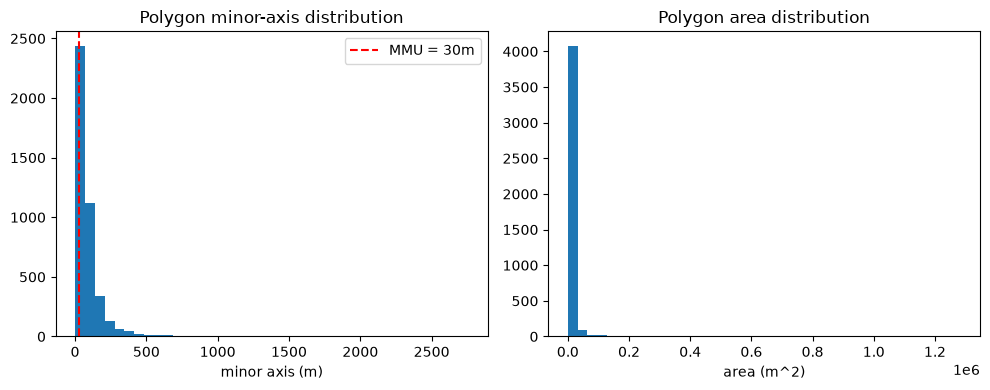

count    4225.000000
mean       94.203243
std       124.388330
min         2.105561
25%        38.793654
50%        62.733286
75%       105.671475
max      2753.977191
Name: minor_axis_m, dtype: float64
count    4.225000e+03
mean     7.404178e+03
std      2.559350e+04
min      5.417242e+00
25%      1.384455e+03
50%      3.044116e+03
75%      6.416253e+03
max      1.283126e+06
Name: area_m2, dtype: float64


In [21]:
labels["area_m2"] = labels.geometry.area

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(labels["minor_axis_m"], bins=40)
axes[0].axvline(MIN_MAPPABLE_UNIT_M, color="red", linestyle="--", label=f"MMU = {MIN_MAPPABLE_UNIT_M}m")
axes[0].set_title("Polygon minor-axis distribution")
axes[0].set_xlabel("minor axis (m)")
axes[0].legend()

axes[1].hist(labels["area_m2"], bins=40)
axes[1].set_title("Polygon area distribution")
axes[1].set_xlabel("area (m^2)")
plt.tight_layout()
plt.show()

print(labels["minor_axis_m"].describe())
print(labels["area_m2"].describe())

## Step 2 — Data acquisition & preprocessing

**Pre-event only.** Every Sentinel-2 scene pulled here must be dated strictly before Nov 28, 2025 — using post-event imagery as input would make the model circular (detecting a scar from its own already-visible signature, not forecasting anything). See `docs/limitations.md`. This is now checked **mechanically** after download (`verify_pre_event_dates`), not just requested via the query and trusted.

**CRS is forced, not assumed.** Both downloads call `resample_spatial` to land on `configs/acquisition.yaml`'s `target_crs`/`target_resolution_m` (EPSG:32644 @ 10m) — without this, Copernicus DEM in particular returns natively in EPSG:4326, which would silently break every downstream function that assumes a metric grid.

Band subset (visible + red edge + NIR + SWIR, not all 13 bands) follows the assignment guidance doc's cited SFFS research: an 8-10 channel subset matches or beats full 13-band input while avoiding the Hughes phenomenon.

### 2.1 — Acquisition helpers

Here we define `connect()` (CDSE OIDC auth), `download_sentinel2()`/`download_dem()` (query + CRS-force + download), and `verify_pre_event_dates()` (the mechanical post-download date check) — nothing in this cell touches the network yet, it only defines functions and self-checks them against synthetic fixtures.

In [22]:
def connect():
    con = openeo.connect("openeo.dataspace.copernicus.eu")
    con.authenticate_oidc_client_credentials(
        client_id=os.environ["CDSE_CLIENT_ID"],
        client_secret=os.environ["CDSE_CLIENT_SECRET"],
    )
    return con


def _search_start(s2_cfg):
    cutoff = date.fromisoformat(s2_cfg["pre_event_cutoff"])
    return (cutoff - timedelta(days=s2_cfg["search_window_days"])).isoformat()


def verify_pre_event_dates(nc_path, cutoff_iso):
    """Mechanically enforce the pre-event constraint on the actual downloaded
    file rather than trusting the request-side temporal_extent filter alone
    (that filter's exclusivity is itself unverified against the live API —
    see download_sentinel2's docstring). Raises on any violation or if no
    recognizable time coordinate exists — this is the real safety net, not
    an assumption.
    """
    import xarray as xr
    cutoff = date.fromisoformat(cutoff_iso)
    with xr.open_dataset(nc_path) as ds:
        time_dim = next((d for d in ("t", "time") if d in ds.coords), None)
        if time_dim is None:
            raise ValueError(
                f"{nc_path}: no time coordinate found (expected 't' or 'time') — "
                "cannot verify pre-event compliance. REQUIRES VERIFICATION against "
                "the actual openEO output structure; do not assume compliance."
            )
        bad = [str(t) for t in ds[time_dim].values if pd.Timestamp(t).date() >= cutoff]
    if bad:
        raise ValueError(f"{nc_path}: {len(bad)} timestamp(s) on/after {cutoff_iso} — pre-event constraint violated: {bad[:3]}")


def _build_sentinel2_cube(con, cfg):
    """Shared query builder for both the sync and batch download paths below
    -- same AOI/date/band/cloud/CRS logic either way, only the execution
    strategy differs.
    """
    aoi, s2 = cfg["aoi"], cfg["sentinel2"]
    cube = con.load_collection(
        s2["collection"],
        spatial_extent={"west": aoi["min_lon"], "south": aoi["min_lat"],
                         "east": aoi["max_lon"], "north": aoi["max_lat"]},
        temporal_extent=[_search_start(s2), s2["pre_event_cutoff"]],
        bands=s2["bands"],
        properties={"eo:cloud_cover": lambda v: v <= s2["max_cloud_cover"]},
    )
    epsg = int(cfg["target_crs"].split(":")[1])
    return cube.resample_spatial(resolution=cfg["target_resolution_m"], projection=epsg)


def download_sentinel2(cfg, out_dir):
    """Download pre-event Sentinel-2 L2A imagery for the AOI, resampled to
    the shared metric CRS/resolution, with the pre-event constraint checked
    mechanically after download (not just requested and trusted).

    Sync only -- CDSE's synchronous endpoint hard-kills requests running
    past 15 minutes server-side (confirmed: SPARK_JOB_CANCELLED after PT15M
    on the real full-country AOI). Use download_sentinel2_batch for
    country-scale requests; this function is for small/pilot AOIs only.
    """
    con = connect()
    cube = _build_sentinel2_cube(con, cfg)
    out_path = Path(out_dir) / "sentinel2_pre_event.nc"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cube.download(out_path)
    verify_pre_event_dates(out_path, cfg["sentinel2"]["pre_event_cutoff"])
    return out_path


def download_sentinel2_batch(cfg, out_dir):
    """Same query as download_sentinel2, run as an openEO batch job instead
    of a synchronous download. Needed for full-scale AOIs: the sync
    endpoint's 15-minute server-side kill isn't a client-timeout problem
    that a bigger `timeout=` value can work around -- the job itself is
    cancelled on the backend regardless of what the client is waiting for.
    """
    con = connect()
    cube = _build_sentinel2_cube(con, cfg)
    job = con.create_job(cube, title="sentinel2_pre_event_batch")
    job.start_and_wait()

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    result_paths = [Path(p) for p in job.get_results().download_files(str(out_dir))]
    for p in result_paths:
        if p.suffix == ".nc":
            verify_pre_event_dates(p, cfg["sentinel2"]["pre_event_cutoff"])
    return result_paths


def download_dem(cfg, out_dir):
    """Download the Copernicus DEM (GLO-30) for the AOI, resampled to the
    shared metric CRS/resolution — static terrain, no date concern, but CRS
    matters just as much as for Sentinel-2.
    """
    con = connect()
    aoi = cfg["aoi"]
    cube = con.load_collection(
        cfg["dem"]["source"],
        spatial_extent={"west": aoi["min_lon"], "south": aoi["min_lat"],
                         "east": aoi["max_lon"], "north": aoi["max_lat"]},
    )
    epsg = int(cfg["target_crs"].split(":")[1])
    cube = cube.resample_spatial(resolution=cfg["target_resolution_m"], projection=epsg)

    out_path = Path(out_dir) / "dem.tif"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cube.download(out_path)

    with rasterio.open(out_path) as ref:
        actual = f"EPSG:{ref.crs.to_epsg()}" if ref.crs else None
        if actual != cfg["target_crs"]:
            raise ValueError(
                f"{out_path}: expected {cfg['target_crs']}, got {actual} — resample_spatial "
                "did not take effect as expected. REQUIRES VERIFICATION against the live backend."
            )
    return out_path


assert _search_start({"pre_event_cutoff": "2025-11-28", "search_window_days": 90}) == "2025-08-30"

# verify_pre_event_dates is checked against a synthetic NetCDF (real openEO
# output structure is unverified until the first live run, per its docstring).
import tempfile
import xarray as xr

with tempfile.TemporaryDirectory() as _tmp:
    _good = Path(_tmp) / "good.nc"
    _bad = Path(_tmp) / "bad.nc"
    xr.Dataset({"B04": (("t", "y", "x"), np.zeros((2, 2, 2)))},
               coords={"t": pd.to_datetime(["2025-08-01", "2025-09-15"])}).to_netcdf(_good)
    xr.Dataset({"B04": (("t", "y", "x"), np.zeros((2, 2, 2)))},
               coords={"t": pd.to_datetime(["2025-08-01", "2025-12-01"])}).to_netcdf(_bad)

    verify_pre_event_dates(_good, "2025-11-28")  # must not raise
    _rejected = False
    try:
        verify_pre_event_dates(_bad, "2025-11-28")
    except ValueError:
        _rejected = True
    assert _rejected, "verify_pre_event_dates should have rejected a post-event timestamp"

### 2.2 — Run Sentinel-2 download

Here we actually call `download_sentinel2_batch()` against the real, full-country AOI — the first cell in the notebook that touches the live network. **Confirmed, not hypothetical:** a plain synchronous `download_sentinel2()` call against this AOI (~150 x 165 km, multiple Sentinel-2 tiles, 90-day window) was tried and killed server-side by CDSE after exactly 15 minutes (`SPARK_JOB_CANCELLED ... PT15M`) — the batch path below is required at this scale, not just a fallback for a slow connection. `download_sentinel2()` (sync) still exists for small/pilot AOIs, where it's faster to iterate with.

In [ ]:
s2_paths = download_sentinel2_batch(acquisition_cfg, DATA_DIR / acquisition_cfg["output_dir"] / "sentinel2")
print(f"Saved {len(s2_paths)} file(s): {s2_paths}")

0:00:00 Job 'j-26082407225549c3bb4b6349d2d1a2bd': send 'start'
0:00:02 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:00:08 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:00:14 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:00:23 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:00:33 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:00:45 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:01:01 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:01:20 Job 'j-26082407225549c3bb4b6349d2d1a2bd': queued (progress 0%)
0:01:44 Job 'j-26082407225549c3bb4b6349d2d1a2bd': running (progress N/A)
0:02:15 Job 'j-26082407225549c3bb4b6349d2d1a2bd': running (progress N/A)
0:02:52 Job 'j-26082407225549c3bb4b6349d2d1a2bd': running (progress N/A)
0:03:39 Job 'j-26082407225549c3bb4b6349d2d1a2bd': running (progress N/A)
0:04:38 Job 'j-26082407225549c3bb4b6349d2d1a2bd': running (progress N/A)
0:05

### 2.3 — Run DEM download

Here we call `download_dem()` for the same AOI — static terrain, no date filter, but the same CRS-forcing and live-network caveats as 2.2 apply.

In [ ]:
dem_path = download_dem(acquisition_cfg, DATA_DIR / acquisition_cfg["output_dir"] / "dem")
print(f"Saved {dem_path}")

### 2.4 — Cloud masking

Here we define `cloud_free_mask()`, which flags Scene Classification Layer pixels to exclude (cloud, shadow, cirrus) so they never enter a training patch unmasked.

In [ ]:
SCL_EXCLUDE = set(preprocessing_cfg["cloud_mask"]["scl_exclude"])  # cloud shadow, cloud low/med/high prob, cirrus


def cloud_free_mask(scl):
    """True where usable (not cloud/shadow/cirrus). Cloud shadows matter
    especially here: they spectrally mimic deep, saturated landslide scars.
    """
    return ~np.isin(scl, list(SCL_EXCLUDE))


_test_scl = np.array([4, 3, 7, 8, 9, 10, 5])  # 4=vegetation, 5=bare soil kept; rest excluded
assert cloud_free_mask(_test_scl).tolist() == [True, False, False, False, False, False, True]

### 2.5 — Spectral indices

Here we define reflectance scaling and three spectral indices — NDVI, BSI, MNDWI — each a normalized band ratio that highlights vegetation loss, exposed soil, and water, respectively.

In [ ]:
REFLECTANCE_SCALE = preprocessing_cfg["reflectance_scale"]  # L2A digital numbers -> reflectance [0, 1]


def to_reflectance(dn):
    return dn.astype(np.float32) * REFLECTANCE_SCALE


def _safe_ratio(numerator, denominator):
    # denominator can hit exactly 0 on masked/no-data pixels.
    safe_denom = np.where(denominator == 0, 1, denominator)
    return np.where(denominator == 0, 0.0, numerator / safe_denom)


def ndvi(red, nir):
    return _safe_ratio(nir - red, nir + red)


def bsi(blue, red, nir, swir1):
    return _safe_ratio((swir1 + red) - (nir + blue), (swir1 + red) + (nir + blue))


def mndwi(green, swir1):
    return _safe_ratio(green - swir1, green + swir1)


assert to_reflectance(np.array([10000]))[0] == 1.0
assert np.allclose(ndvi(np.array([0.1, 0.5]), np.array([0.4, 0.5])), [0.6, 0.0])
assert ndvi(np.array([0.0]), np.array([0.0]))[0] == 0.0

# bsi/mndwi share ndvi's formula shape, so a transposed band argument is
# an easy mistake -- both checked explicitly, not just ndvi.
_blue, _red, _nir, _swir1, _green = (np.array([v]) for v in (0.1, 0.2, 0.5, 0.3, 0.15))
assert np.allclose(bsi(_blue, _red, _nir, _swir1), [((0.3 + 0.2) - (0.5 + 0.1)) / ((0.3 + 0.2) + (0.5 + 0.1))])
assert np.allclose(mndwi(_green, _swir1), [(0.15 - 0.3) / (0.15 + 0.3)])
assert mndwi(np.array([0.0]), np.array([0.0]))[0] == 0.0

### 2.6 — Terrain: slope & aspect

Here we compute slope (steepness) and aspect (downhill compass direction) from the DEM via finite-difference gradients — two of the three terrain channels that go into every patch.

In [ ]:
def slope_aspect(dem, resolution_m):
    """Slope (degrees) and aspect (compass degrees, clockwise from North =
    downhill direction) from a DEM array via simple finite-difference
    gradients — enough to stratify negative samples by terrain (Step 3). A
    full Horn (1981) 3x3 kernel or TWI (needs flow-accumulation routing) is
    NOT implemented here; that's a documented gap (see docs/limitations.md),
    not a silent approximation of it.
    """
    dzdy, dzdx = np.gradient(dem.astype(np.float64), resolution_m)
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    aspect = np.degrees(np.arctan2(-dzdx, dzdy)) % 360
    return slope, aspect


# Eastward-rising plane (higher to the east) -> slope faces west -> aspect ~270 deg.
_plane_e = np.fromfunction(lambda r, c: c * 5.0, (10, 10))  # 5m rise per 10m pixel, eastward
_slope_e, _aspect_e = slope_aspect(_plane_e, resolution_m=10)
assert np.allclose(_slope_e[2:-2, 2:-2], np.degrees(np.arctan(0.5)), atol=0.5)
assert np.allclose(_aspect_e[2:-2, 2:-2], 270.0, atol=1.0)

# Southward-rising plane (higher to the south) -> slope faces north -> aspect ~0 deg.
# Asserted explicitly (not just slope) so a row-axis sign regression wouldn't
# pass unnoticed.
_plane_s = np.fromfunction(lambda r, c: r * 5.0, (10, 10))
_slope_s, _aspect_s = slope_aspect(_plane_s, resolution_m=10)
assert np.allclose(_aspect_s[2:-2, 2:-2] % 360, 0.0, atol=1.0)

### 2.7 — Terrain: curvature

Here we compute profile curvature (whether terrain is convex/ridge or concave/valley) — the third terrain channel alongside slope/aspect.

In [ ]:
def curvature(dem, resolution_m):
    """Profile curvature (second derivative of elevation): positive = convex
    (ridge, flow diverges, material tends to detach), negative = concave
    (valley, flow and debris converge and accumulate). Landslide
    susceptibility studies consistently treat these as distinct terrain
    regimes, not just steeper-vs-flatter slope.

    Computed as -(d2z/dx2 + d2z/dy2) via two passes of np.gradient — a
    second-difference approximation, not a full Zevenbergen & Thorne (1987)
    3x3 kernel. Same documented-gap pattern as TWI/Horn slope (see
    docs/limitations.md): coarse enough for terrain stratification, not
    precision geomorphometry.
    """
    dzdy, dzdx = np.gradient(dem.astype(np.float64), resolution_m)
    d2zdy2, _ = np.gradient(dzdy, resolution_m)
    _, d2zdx2 = np.gradient(dzdx, resolution_m)
    return -(d2zdx2 + d2zdy2)


# Dome (peak at center, falls off outward) = a ridge -> curvature > 0.
_dome = np.fromfunction(lambda r, c: -0.05 * ((r - 30) ** 2 + (c - 30) ** 2), (60, 60))
_curv_dome = curvature(_dome, resolution_m=1)
assert np.all(_curv_dome[10:-10, 10:-10] > 0)

# Bowl (trough at center, rises outward) = a valley -> curvature < 0.
_bowl = np.fromfunction(lambda r, c: 0.05 * ((r - 30) ** 2 + (c - 30) ** 2), (60, 60))
_curv_bowl = curvature(_bowl, resolution_m=1)
assert np.all(_curv_bowl[10:-10, 10:-10] < 0)

### 2.8 — Label rasterization

Here we burn the label polygons into a pixel mask aligned to the imagery grid, splitting off polygons under the minimum mappable unit into a separate small-object mask instead of dropping or blending them in.

In [ ]:
def rasterize_labels(labels_gdf, shape, transform, min_minor_axis_m=None):
    """Burn label polygons to a pixel mask. Polygons below the minimum
    mappable unit go to a separate small-object mask instead of the main
    training target (see docs/limitations.md), so recall on them is
    measured, not silently dropped or silently blended in.

    all_touched=True: a polygon narrower than one pixel can otherwise miss
    every pixel *center* and vanish entirely (rasterio's all_touched=False
    default) — exactly the sub-pixel population this split exists to
    preserve. The tradeoff (slightly over-inclusive boundaries on larger
    polygons) is acceptable for a "did a landslide touch this pixel" mask.
    """
    min_minor_axis_m = MIN_MAPPABLE_UNIT_M if min_minor_axis_m is None else min_minor_axis_m
    main = labels_gdf[labels_gdf["minor_axis_m"] >= min_minor_axis_m]
    small = labels_gdf[labels_gdf["minor_axis_m"] < min_minor_axis_m]
    return _burn(main, shape, transform), _burn(small, shape, transform)


def _burn(gdf, shape, transform):
    if len(gdf) == 0:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize([(g, 1) for g in gdf.geometry], out_shape=shape, transform=transform,
                      fill=0, dtype=np.uint8, all_touched=True)


_ref_transform = from_origin(0, 200, 10, 10)  # 20x20 px @ 10m
_test_gdf = gpd.GeoDataFrame(
    {"minor_axis_m": [50.0, 10.0]},
    geometry=[box(20, 20, 70, 70), box(120, 120, 130, 130)],
    crs=METRIC_CRS,
)
_mask, _small_mask = rasterize_labels(_test_gdf, (20, 20), _ref_transform)
assert _mask.sum() > 0 and _small_mask.sum() > 0 and not np.any(_mask & _small_mask)

# A sub-pixel polygon whose center falls between pixel centers must still
# register with all_touched=True (this is exactly the bug that was fixed).
_tiny = gpd.GeoDataFrame({"minor_axis_m": [8.0]}, geometry=[box(24, 24, 28, 28)], crs=METRIC_CRS)
_, _tiny_mask = rasterize_labels(_tiny, (20, 20), _ref_transform)
assert _tiny_mask.sum() > 0

### 2.9 — Patch tiling

Here we define the sliding-window generator that tiles a full scene into 256x256 @ 10m patches with 50% stride overlap, used by both training-time extraction and any full-scene inference pass.

In [ ]:
def iter_patches(dataset, size=256, stride=128):
    """Yield (window, transform) tiling an OPEN rasterio dataset.

    256x256 @ 10m (2.56km) comfortably contains even the p99 landslide
    polygon (917m wide, see docs/data_card.md); stride 128 (50% overlap)
    keeps edge-adjacent polygons fully inside the *next* tile too. Only
    full patches are yielded — partial edge strips are dropped.
    """
    for row in range(0, dataset.height - size + 1, stride):
        for col in range(0, dataset.width - size + 1, stride):
            window = Window(col, row, size, size)
            yield window, dataset.window_transform(window)


# Non-square raster (640 tall x 512 wide) so a height/width axis swap inside
# the function would change the row/col step *counts*, not just leave the
# total product unchanged (a square fixture can't distinguish that bug).
with MemoryFile() as _memfile:
    with _memfile.open(driver="GTiff", height=640, width=512, count=1, dtype="uint8",
                        crs=METRIC_CRS, transform=from_origin(0, 640, 1, 1)) as _ds:
        _ds.write(np.zeros((640, 512), dtype=np.uint8), 1)
    with _memfile.open() as _ds:
        _patches = list(iter_patches(_ds, size=256, stride=128))
_row_offs = sorted({w.row_off for w, _ in _patches})
_col_offs = sorted({w.col_off for w, _ in _patches})
assert len(_row_offs) == 4  # (640-256)/128 + 1
assert len(_col_offs) == 3  # (512-256)/128 + 1
assert len(_patches) == 12

### 2.10 — Patch extraction

Here we tie 2.4–2.9 together: crop one window's worth of bands/SCL/DEM, cloud-mask it, compute indices + terrain, and stack everything into the final (channels, H, W) array a model actually consumes.

In [ ]:
BAND_ORDER = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]


def extract_patch(bands, scl, dem, window, resolution_m):
    """Crop pre-loaded band/SCL/DEM arrays to `window`, cloud-mask, compute
    spectral indices + terrain, and stack into one (channels, H, W) array
    in a fixed channel order. `positive_patch_window` only computes *where*
    to crop; this is the step that actually touches pixel data.

    `bands`: dict of band name -> full-scene 2D reflectance array.
    Indices needing a band that isn't present are simply skipped.
    """
    row0, col0, h, w = window.row_off, window.col_off, window.height, window.width

    def crop(a):
        return a[row0:row0 + h, col0:col0 + w]

    cropped = {b: crop(bands[b]) for b in BAND_ORDER if b in bands}
    mask = cloud_free_mask(crop(scl))

    channels = [cropped[b] for b in BAND_ORDER if b in cropped]
    if "B04" in cropped and "B08" in cropped:
        channels.append(ndvi(cropped["B04"], cropped["B08"]))
    if all(k in cropped for k in ("B02", "B04", "B08", "B11")):
        channels.append(bsi(cropped["B02"], cropped["B04"], cropped["B08"], cropped["B11"]))
    if "B03" in cropped and "B11" in cropped:
        channels.append(mndwi(cropped["B03"], cropped["B11"]))

    slope, aspect = slope_aspect(crop(dem), resolution_m)
    curv = curvature(crop(dem), resolution_m)
    channels.extend([slope, aspect, curv])

    stack = np.stack(channels).astype(np.float32)
    stack = stack * mask  # zero cloud/shadow pixels rather than silently keeping contaminated values
    return stack, mask


_h = _w = 20
_syn_bands = {b: np.random.rand(_h, _w).astype(np.float32) for b in ("B02", "B03", "B04", "B08", "B11")}
_syn_scl = np.full((_h, _w), 4, dtype=np.uint8)
_syn_scl[0:5, 0:5] = 9  # a cloud patch
_syn_dem = np.fromfunction(lambda r, c: c * 2.0, (_h, _w))
_syn_window = Window(2, 2, 10, 10)

_stack, _mask = extract_patch(_syn_bands, _syn_scl, _syn_dem, _syn_window, resolution_m=10)
assert _stack.shape == (5 + 3 + 3, 10, 10)  # 5 bands + NDVI/BSI/MNDWI + slope/aspect/curvature
assert (_stack[:, 0:3, 0:3] == 0).all()  # the cloud patch (rows/cols 0-2 of the crop) is zeroed

### 2.11 — Load real acquisition outputs

Here we define the two functions that turn a downloaded Sentinel-2 NetCDF and DEM GeoTIFF into the (bands dict, scl array, dem array, transform) shape every function above already expects — the actual glue between a real download (2.2/2.3) and everything else in this notebook.

In [ ]:
def load_sentinel2_scene(nc_path):
    """Open a downloaded Sentinel-2 NetCDF (one AOI, one matched date) and
    return (bands, scl, transform, resolution_m, sensing_date) for its single
    time slice, with reflectance scaling already applied to each band.
    """
    import xarray as xr
    with xr.open_dataset(nc_path) as ds:
        resolution_m = float(abs(ds.x.values[1] - ds.x.values[0]))
        west = float(ds.x.values[0]) - resolution_m / 2
        north = float(ds.y.values[0]) + resolution_m / 2
        transform = from_origin(west, north, resolution_m, resolution_m)
        bands = {b: to_reflectance(ds[b].isel(t=0).values) for b in BAND_ORDER if b in ds}
        scl = ds["SCL"].isel(t=0).values.astype(np.uint8) if "SCL" in ds.data_vars else None
        sensing_date = pd.Timestamp(ds.t.values[0]).date().isoformat()
    return bands, scl, transform, resolution_m, sensing_date


def load_dem_aligned(dem_path, target_transform, target_shape, target_crs):
    """DEM resampled onto the Sentinel-2 scene's exact pixel grid. openEO
    resamples each collection independently, so two collections at the same
    nominal CRS/resolution can still be offset by a fraction of a pixel.
    """
    from rasterio.warp import reproject, Resampling
    with rasterio.open(dem_path) as src:
        dem = np.zeros(target_shape, dtype=np.float32)
        reproject(source=rasterio.band(src, 1), destination=dem,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=target_transform, dst_crs=target_crs,
                  resampling=Resampling.bilinear)
    return dem


# Self-check: DEM reprojected onto a deliberately shifted target grid still
# produces a correctly-shaped, non-empty result.
with tempfile.TemporaryDirectory() as _tmp_dem:
    _dem_check_path = Path(_tmp_dem) / "dem.tif"
    _src_transform = from_origin(1000, 2000, 10, 10)
    _src_dem = np.fromfunction(lambda r, c: c * 1.0, (50, 50)).astype(np.float32)
    with rasterio.open(_dem_check_path, "w", driver="GTiff", height=50, width=50, count=1,
                        dtype="float32", crs=METRIC_CRS, transform=_src_transform) as _dst:
        _dst.write(_src_dem, 1)
    _aligned_dem = load_dem_aligned(_dem_check_path, from_origin(1002, 1998, 10, 10), (50, 50), METRIC_CRS)
assert _aligned_dem.shape == (50, 50)
assert _aligned_dem.max() > 0

Run once you have real `s2_paths`/`dem_path` from 2.2/2.3 — this cell needs live download output and is not executed automatically. `s2_paths` is a list (batch jobs can return multiple result files); this picks the first `.nc` among them.

In [ ]:
s2_path = next(p for p in s2_paths if Path(p).suffix == ".nc")
bands, scl, transform, resolution_m, sensing_date = load_sentinel2_scene(s2_path)
dem = load_dem_aligned(dem_path, transform, scl.shape, METRIC_CRS)
print(f"Real scene loaded: {scl.shape} px @ {resolution_m}m, sensing_date={sensing_date}")

## Step 3 — Sample generation & spatial cross-validation

No district/date/severity attribute exists anywhere in the source data (see `docs/data_card.md`), so spatial clusters for cross-validation are computed here (K-Means on centroids), not read from a field. Negatives are matched to the positive slope distribution (density-proportional, not just range-matched) instead of drawn randomly, and hard negatives are drawn adjacent to real failures — random-only negatives would be trivially separable by slope alone and would never test the model on the genuinely ambiguous, adjacent terrain.

### 3.1 — Spatial clustering

Here we run K-Means on polygon centroids to assign each label a cluster, then check the resulting cluster sizes are reasonably balanced — clusters are the unit that cross-validation folds hold out.

In [ ]:
def assign_spatial_clusters(labels_gdf, n_clusters=None, random_state=None):
    """K-Means over polygon centroids — the only grouping available (see above)."""
    n_clusters = spatial_cv_cfg["clustering"]["n_clusters"] if n_clusters is None else n_clusters
    random_state = RANDOM_SEED if random_state is None else random_state
    centroids = np.column_stack([labels_gdf.geometry.centroid.x, labels_gdf.geometry.centroid.y])
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    return km.fit_predict(centroids)


labels["cluster"] = assign_spatial_clusters(labels)

# Cluster-balance sanity check: a very uneven K-Means split makes one
# held-out fold statistically weak regardless of the buffering logic being
# correct. Flags, does not block — an imbalanced-but-real cluster is still
# more honest than forcing artificial balance.
_cluster_share = labels["cluster"].value_counts(normalize=True).sort_index()
print(f"Cluster sizes: {dict(labels['cluster'].value_counts().sort_index())}")
print(f"Cluster share range: {_cluster_share.min():.1%} - {_cluster_share.max():.1%}")
if _cluster_share.max() > 0.30 or _cluster_share.min() < 0.02:
    print("NOTE: cluster sizes are notably imbalanced — treat that fold's metrics with extra caution.")
labels["cluster"].value_counts().sort_index()

Cluster sizes: {0: np.int64(438), 1: np.int64(839), 2: np.int64(281), 3: np.int64(632), 4: np.int64(385), 5: np.int64(607), 6: np.int64(237), 7: np.int64(806)}
Cluster share range: 5.6% - 19.9%


cluster
0    438
1    839
2    281
3    632
4    385
5    607
6    237
7    806
Name: count, dtype: int64

### 3.2 — Cluster visualization

Here we plot the label polygons colored by cluster, as a visual sanity check that clusters are spatially coherent, not scattered.

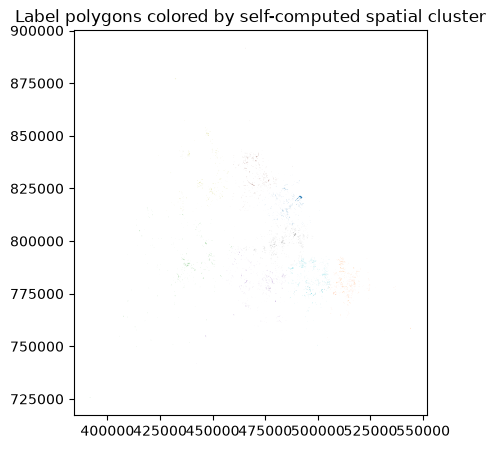

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
labels.plot(column="cluster", cmap="tab10", ax=ax, legend=False)
ax.set_title("Label polygons colored by self-computed spatial cluster")
ax.set_aspect("equal")
plt.show()

### 3.3 — Buffered cross-validation folds

Here we generate one fold per cluster, holding it out entirely and stripping any training polygon within the buffer distance of it — the mechanism that actually prevents spatial leakage between train and test.

In [ ]:
def buffered_cluster_folds(gdf, cluster_col="cluster", buffer_m=None):
    """Yield (test_cluster_id, train_idx, test_idx) holding out one whole
    cluster at a time, with any train polygon within buffer_m of the test
    cluster's geometry excluded — strips cross-boundary spatial
    autocorrelation that plain block CV would still leak (Tobler's First
    Law). No random-fold option exists in this API: random k-fold is
    rejected by omission, not by a runtime check.
    """
    buffer_m = spatial_cv_cfg["buffer_m"] if buffer_m is None else buffer_m
    for test_cluster in sorted(gdf[cluster_col].unique()):
        test_mask = gdf[cluster_col] == test_cluster
        test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)
        train_mask = (~test_mask) & (~gdf.geometry.intersects(test_geom))
        yield test_cluster, gdf.index[train_mask].to_numpy(), gdf.index[test_mask].to_numpy()


_check_buffer_m = spatial_cv_cfg["buffer_m"]
for _test_cluster, _train_idx, _test_idx in buffered_cluster_folds(labels, buffer_m=_check_buffer_m):
    assert not set(_train_idx) & set(_test_idx)
    _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(_check_buffer_m)  # reuses the same value, not a second hardcoded literal
    assert not labels.loc[_train_idx, "geometry"].intersects(_test_geom).any()
print(f"{labels['cluster'].nunique()} clusters -> {labels['cluster'].nunique()} buffered folds, all leakage-checked")

C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(_check_buffer_m)  # reuses the same value, not a second hardcoded literal


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(_check_buffer_m)  # reuses the same value, not a second hardcoded literal


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


...

C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(_check_buffer_m)  # reuses the same value, not a second hardcoded literal


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\4095830638.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(_check_buffer_m)  # reuses the same value, not a second hardcoded literal


8 clusters -> 8 buffered folds, all leakage-checked


### 3.4 — Positive sample windows

Here we convert a polygon centroid (world coordinates) into the pixel window used to crop a positive training patch around it.

In [ ]:
def positive_patch_window(centroid_xy, transform, size=256):
    """Pixel window centered on a polygon's centroid (world coords), for
    positive-sample extraction from pre-event imagery (paired with
    extract_patch, above, for the actual pixel read). Caller must clip the
    returned window against the raster's actual bounds before reading;
    that's not handled here.
    """
    col, row = ~transform * centroid_xy
    half = size // 2
    # math.floor, not int(): int() truncates toward zero, which is wrong
    # for negative fractional pixel coordinates (centroids west/north of a
    # raster's origin) -- exactly the near-edge case this function's own
    # docstring flags as the caller's responsibility to handle downstream.
    return Window(math.floor(col) - half, math.floor(row) - half, size, size)


# Asymmetric transform/centroid (col != row numerically) so a col/row swap
# inside the function would be caught -- a symmetric fixture can't tell.
_transform = from_origin(0, 1000, 10, 10)
_win = positive_patch_window((300, 500), _transform, size=256)
assert (_win.col_off, _win.row_off) == (30 - 128, 50 - 128)

# Negative fractional pixel coordinate: centroid west of the raster's origin column.
_win_neg = positive_patch_window((-4, 500), _transform, size=256)
assert _win_neg.col_off == math.floor(-0.4) - 128 == -1 - 128

### 3.5 — Slope-stratified negative sampling

Here we pick negative-sample pixel locations so their slope distribution matches the positives' shape (not just random background), excluding anything too close to a real polygon.

In [ ]:
def _to_points(candidates, transform):
    xs, ys = rasterio.transform.xy(transform, [r for r, c in candidates], [c for r, c in candidates])
    return gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs=METRIC_CRS)


def slope_stratified_negative_candidates(dem, transform, resolution_m, positive_slopes_deg,
                                          exclusion_geom, n_total=None, bins=None, rng=None):
    """Candidate (row, col) pixel locations for negatives, density-stratified
    to match the *shape* of the positive polygons' slope distribution (a bin
    holding more positives draws proportionally more negatives, not a flat
    n_per_bin regardless of density), and excluded from within
    `exclusion_geom` (a buffered union of positive polygons, per
    configs/spatial_cv.yaml) — see docs/limitations.md on why random
    negatives (trivially separable by slope alone) are rejected.
    """
    cfg = spatial_cv_cfg["negative_sampling"]
    n_total = 100 if n_total is None else n_total
    bins = cfg["slope_bins"] if bins is None else bins
    rng = rng or np.random.default_rng(RANDOM_SEED)

    slope, _ = slope_aspect(dem, resolution_m)
    edges = np.histogram_bin_edges(positive_slopes_deg, bins=bins)
    pos_counts, _ = np.histogram(positive_slopes_deg, bins=edges)
    n_per_bin = np.maximum(1, np.round(n_total * pos_counts / max(pos_counts.sum(), 1))).astype(int)

    candidates = []
    n_bins = len(edges) - 1
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        is_last = i == n_bins - 1
        in_bin = (slope >= lo) & ((slope <= hi) if is_last else (slope < hi))  # last bin closed on both ends, like np.histogram
        rows, cols = np.where(in_bin)
        if len(rows) == 0:
            continue
        pick = rng.choice(len(rows), size=min(n_per_bin[i], len(rows)), replace=False)
        candidates.extend(zip(rows[pick], cols[pick]))

    if not candidates:
        return []
    points = _to_points(candidates, transform)
    keep = ~points.within(exclusion_geom)
    return [rc for rc, k in zip(candidates, keep) if k]


# --- Self-check 1: multi-bin stratification. Two clearly different slope
# regions (left vs right) so both bins are genuinely exercised, not just one.
_strat_dem = np.zeros((60, 60))
for _col in range(60):
    _strat_dem[:, _col] = (1.0 * _col) if _col < 30 else (30.0 + 8.0 * (_col - 30))
_strat_slope, _ = slope_aspect(_strat_dem, resolution_m=10)
_no_op_exclusion = box(-1000, -1000, -999, -999)  # far away -> excludes nothing, isolates stratification from exclusion
_strat_candidates = slope_stratified_negative_candidates(
    _strat_dem, from_origin(0, 600, 10, 10), 10, positive_slopes_deg=np.array([5.0, 6.0, 38.0, 39.0, 40.0]),
    exclusion_geom=_no_op_exclusion, n_total=40, bins=4, rng=np.random.default_rng(1),
)
_cand_slopes = [_strat_slope[r, c] for r, c in _strat_candidates]
assert len(_cand_slopes) > 0
assert min(_cand_slopes) < 10 and max(_cand_slopes) > 30  # both the gentle and steep regions actually contributed

# --- Self-check 2: exclusion-buffer correctness (uniform DEM, isolates the
# exclusion logic from stratification).
_dem = np.fromfunction(lambda r, c: c * 2.0, (50, 50))
_transform2 = from_origin(0, 500, 10, 10)
_exclusion = box(-10, 390, 510, 510)  # excludes rows 0-11 (all columns)
_excl_candidates = slope_stratified_negative_candidates(
    _dem, _transform2, 10, positive_slopes_deg=np.array([5.0, 8.0, 12.0]),
    exclusion_geom=_exclusion, n_total=30, bins=3, rng=np.random.default_rng(1),
)
assert len(_excl_candidates) > 0
assert all(r >= 12 for r, c in _excl_candidates)

### 3.6 — Hard negative sampling

Here we pick negatives from a ring just outside each polygon's exclusion buffer — adjacent to real failures without overlapping them — so the model is tested on genuinely ambiguous terrain, not just easy background.

In [ ]:
def hard_negative_candidates(dem, transform, exclusion_geom, ring_outer_geom, n_total=50, rng=None):
    """Negatives drawn from the ring immediately outside the exclusion
    buffer but inside a slightly larger radius — adjacent to real failures
    (same rainfall event, same rough geomorphology) without overlapping
    them. These are the "hard negatives" the project plan calls for.

    Intended usage: a local DEM crop around one storm-affected catchment,
    not the full country-wide AOI at once — this enumerates every pixel in
    `dem` before filtering, which is fine for a local window but would be
    wasteful (and pointless, since the ring is local anyway) at full-AOI scale.
    """
    rng = rng or np.random.default_rng(RANDOM_SEED)
    all_rows, all_cols = np.where(np.ones(dem.shape, dtype=bool))
    candidates = list(zip(all_rows, all_cols))
    points = _to_points(candidates, transform)
    keep = (~points.within(exclusion_geom)) & points.within(ring_outer_geom)
    ring_candidates = [rc for rc, k in zip(candidates, keep) if k]
    if len(ring_candidates) > n_total:
        idx = rng.choice(len(ring_candidates), size=n_total, replace=False)
        ring_candidates = [ring_candidates[i] for i in idx]
    return ring_candidates


_hn_dem = np.zeros((60, 60))
_hn_transform = from_origin(0, 600, 10, 10)
_hn_exclusion = box(200, 200, 400, 400)   # inner keep-out (the polygon itself + its buffer)
_hn_ring_outer = box(100, 100, 500, 500)  # outer bound of the "adjacent" ring
_hard_negs = hard_negative_candidates(_hn_dem, _hn_transform, _hn_exclusion, _hn_ring_outer,
                                       n_total=20, rng=np.random.default_rng(2))
assert len(_hard_negs) > 0
_hn_points = _to_points(_hard_negs, _hn_transform)
assert not _hn_points.within(_hn_exclusion).any()   # none inside the excluded polygon buffer
assert _hn_points.within(_hn_ring_outer).all()      # all within the adjacency ring

### 3.7 — Provenance manifest

Here we define and persist the per-patch audit trail (source product, sensing date, cluster, positive/negative) that makes the pre-event-only constraint independently checkable rather than assumed.

In [ ]:
def manifest_row(patch_id, product_id, sensing_date, cluster, is_positive):
    """One row of the provenance manifest — the audit trail that makes
    'pre-event-only' compliance independently checkable rather than assumed
    (see docs/limitations.md).
    """
    assert date.fromisoformat(sensing_date) < date.fromisoformat("2025-11-28"), (
        f"patch {patch_id}: sensing_date {sensing_date} is not strictly pre-event"
    )
    return {"patch_id": patch_id, "product_id": product_id, "sensing_date": sensing_date,
            "cluster": cluster, "is_positive": is_positive}


_manifest_rows = []


def append_to_manifest(row):
    _manifest_rows.append(row)


def save_manifest(path):
    """Persist accumulated manifest rows to disk. Called once per real
    patch-generation run; demonstrated here on the self-test rows below
    until real imagery exists.
    """
    df = pd.DataFrame(_manifest_rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df


append_to_manifest(manifest_row("p0001", "S2B_MSIL2A_20250801T...", "2025-08-01", cluster=3, is_positive=True))

_rejected = False
try:
    manifest_row("bad", "x", "2025-12-01", cluster=0, is_positive=False)
except AssertionError:
    _rejected = True
assert _rejected, "should have rejected a post-event date"

_manifest_demo_path = DATA_DIR / "processed" / "manifest_demo.csv"
_saved = save_manifest(_manifest_demo_path)
assert _manifest_demo_path.exists() and len(_saved) == 1
print(f"Demo manifest persisted to {_manifest_demo_path} ({len(_saved)} row) — real accumulation happens once real patches exist.")

Demo manifest persisted to f:\Landslide-Forecasting-System\data\processed\manifest_demo.csv (1 row) — real accumulation happens once real patches exist.


## Step 4 — Modeling

Two architectures, per the locked project plan: a U-Net baseline and a DeepLabV3+ comparison model, both from `segmentation_models_pytorch`, both taking the same stacked channel input from `extract_patch` (Step 2). Loss is a Focal+Dice hybrid — plain cross-entropy/accuracy is invalid here given the extreme class imbalance (a median landslide is ~0.05% of a 256x256 patch, see `docs/data_card.md`).

**No real Sentinel-2/DEM imagery exists yet**, so nothing below is trained on real data. Every check here is the modeling equivalent of Steps 1-3's synthetic self-checks: proof the mechanics work (dataset streaming, model forward pass, loss behaves correctly, a training loop actually reduces loss on a toy batch), not a claim about real-world performance.

### 4.1 — Dataset streaming

Here we wrap patch extraction in a PyTorch `Dataset` that reads one patch lazily per `__getitem__` call, instead of preloading the whole AOI into RAM.

In [ ]:
class LandslideDataset(torch.utils.data.Dataset):
    """Lazily extracts one patch per sample via extract_patch() instead of
    preloading every patch into RAM up front — a full-AOI multi-band stack
    would be tens of GB. Streaming through a DataLoader (below) is what
    makes this actually memory-safe at real scale.
    """

    def __init__(self, centroids_xy, bands, scl, dem, mask_full, transform, resolution_m, size=256):
        self.centroids_xy = centroids_xy
        self.bands, self.scl, self.dem, self.mask_full = bands, scl, dem, mask_full
        self.transform, self.resolution_m, self.size = transform, resolution_m, size

    def __len__(self):
        return len(self.centroids_xy)

    def __getitem__(self, idx):
        window = positive_patch_window(self.centroids_xy[idx], self.transform, size=self.size)
        x, _ = extract_patch(self.bands, self.scl, self.dem, window, self.resolution_m)
        row0, col0 = window.row_off, window.col_off
        y = self.mask_full[row0:row0 + window.height, col0:col0 + window.width]
        return torch.from_numpy(x), torch.from_numpy(y.astype(np.float32))


_scene = 600
_ds_bands = {b: np.random.rand(_scene, _scene).astype(np.float32) for b in BAND_ORDER}
_ds_scl = np.full((_scene, _scene), 4, dtype=np.uint8)
_ds_dem = np.fromfunction(lambda r, c: c * 1.5, (_scene, _scene))
_ds_mask_full = np.zeros((_scene, _scene), dtype=np.uint8)
_ds_transform = from_origin(0, _scene * 10, 10, 10)
_ds_centroids = [(2500, 2500), (3000, 3000)]  # comfortably inside bounds for a 64px patch

_dataset = LandslideDataset(_ds_centroids, _ds_bands, _ds_scl, _ds_dem, _ds_mask_full,
                             _ds_transform, resolution_m=10, size=64)
assert len(_dataset) == 2
_x0, _y0 = _dataset[0]
assert isinstance(_x0, torch.Tensor) and isinstance(_y0, torch.Tensor)
assert _x0.shape == (len(BAND_ORDER) + 3 + 3, 64, 64)
assert _y0.shape == (64, 64)

### 4.2 — Assemble a real training sample set

Here we combine label loading (1.3), rasterization (2.8), and positive/negative/hard-negative sampling (3.4-3.6) into one real `LandslideDataset` (4.1) — the assembly step connecting a real downloaded scene to actual training samples, distinct from each sampling function's own isolated self-check above.

In [ ]:
def labels_within_bounds(labels_gdf, transform, shape, patch_size):
    """Keep only labels whose centroid is far enough from the scene edge
    that a patch_size window centered on it fits entirely inside the scene.
    positive_patch_window's own docstring flags edge-clipping as the
    caller's responsibility -- this is where that's actually handled.
    """
    height, width = shape
    half = patch_size // 2
    xs = labels_gdf.geometry.centroid.x.to_numpy()
    ys = labels_gdf.geometry.centroid.y.to_numpy()
    cols, rows = ~transform * (xs, ys)
    inside = (rows >= half) & (rows < height - half) & (cols >= half) & (cols < width - half)
    return labels_gdf[inside]


def _filter_candidates_by_margin(candidates, shape, patch_size):
    half = patch_size // 2
    height, width = shape
    return [(r, c) for r, c in candidates if half <= r < height - half and half <= c < width - half]


def build_real_dataset(labels_gdf, bands, scl, dem, transform, resolution_m, patch_size=None):
    """Assemble a real LandslideDataset from downloaded imagery: one positive
    sample per label polygon inside the scene, plus a matched set of
    slope-stratified and hard negatives -- the glue between Step 2's
    acquisition and this model.
    """
    patch_size = preprocessing_cfg["patch"]["size_px"] if patch_size is None else patch_size
    scene_shape = dem.shape
    in_scene = labels_within_bounds(labels_gdf, transform, scene_shape, patch_size)

    mask_full, _ = rasterize_labels(labels_gdf, scene_shape, transform)
    positive_centroids = list(zip(in_scene.geometry.centroid.x, in_scene.geometry.centroid.y))

    neg_cfg = spatial_cv_cfg["negative_sampling"]
    exclusion_geom = in_scene.geometry.buffer(neg_cfg["exclusion_buffer_m"]).unary_union
    ring_geom = in_scene.geometry.buffer(neg_cfg["hard_negative_ring_m"]).unary_union
    slope, _ = slope_aspect(dem, resolution_m)
    pos_slopes = slope[mask_full.astype(bool)]
    if len(pos_slopes) == 0:
        pos_slopes = np.array([10.0])  # no positive pixels in this scene -- fall back to a neutral slope

    n_neg = max(1, len(positive_centroids))
    rng = np.random.default_rng(RANDOM_SEED)
    neg_candidates = _filter_candidates_by_margin(
        slope_stratified_negative_candidates(dem, transform, resolution_m, pos_slopes, exclusion_geom, n_total=n_neg, rng=rng),
        scene_shape, patch_size)
    hard_neg_candidates = _filter_candidates_by_margin(
        hard_negative_candidates(dem, transform, exclusion_geom, ring_geom, n_total=max(1, n_neg // 2), rng=rng),
        scene_shape, patch_size)

    neg_points = _to_points(neg_candidates + hard_neg_candidates, transform) if (neg_candidates or hard_neg_candidates) else []
    negative_centroids = list(zip(neg_points.x, neg_points.y)) if len(neg_points) else []

    all_centroids = positive_centroids + negative_centroids
    is_positive = [True] * len(positive_centroids) + [False] * len(negative_centroids)
    dataset = LandslideDataset(all_centroids, bands, scl, dem, mask_full, transform, resolution_m, size=patch_size)
    return dataset, is_positive, in_scene


# Self-check: fully synthetic scene with one known positive polygon, proving
# the assembly produces at least the one expected positive plus some negatives.
_bd_dem = np.fromfunction(lambda r, c: c * 1.5, (300, 300)).astype(np.float64)
_bd_transform = from_origin(0, 3000, 10, 10)
_bd_bands = {b: np.random.rand(300, 300).astype(np.float32) for b in BAND_ORDER}
_bd_scl = np.full((300, 300), 4, dtype=np.uint8)
_bd_labels = gpd.GeoDataFrame(
    {"minor_axis_m": [40.0]}, geometry=[box(1400, 1400, 1450, 1450)], crs=METRIC_CRS)
_bd_dataset, _bd_is_positive, _bd_in_scene = build_real_dataset(
    _bd_labels, _bd_bands, _bd_scl, _bd_dem, _bd_transform, resolution_m=10, patch_size=64)
assert len(_bd_in_scene) == 1
assert sum(_bd_is_positive) == 1
assert len(_bd_dataset) == len(_bd_is_positive)
_bd_x0, _bd_y0 = _bd_dataset[0]
assert _bd_x0.shape[1:] == (64, 64)

C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\1820330639.py:36: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  exclusion_geom = in_scene.geometry.buffer(neg_cfg["exclusion_buffer_m"]).unary_union
C:\Users\hasha\AppData\Local\Temp\ipykernel_13908\1820330639.py:37: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring_geom = in_scene.geometry.buffer(neg_cfg["hard_negative_ring_m"]).unary_union


Run once 2.11's real scene-loading cell has produced `bands`/`scl`/`dem`/`transform` — needs real data, not executed automatically.

In [ ]:
real_dataset, is_positive, in_scene_labels = build_real_dataset(labels, bands, scl, dem, transform, resolution_m)
print(f"{len(real_dataset)} real patches assembled ({sum(is_positive)} positive, "
      f"{len(is_positive) - sum(is_positive)} negative) from {len(in_scene_labels)} label(s) inside the downloaded scene.")

### 4.3 — Model factory

Here we define `build_model()`, a thin wrapper over `segmentation_models_pytorch` that builds either the U-Net baseline or the DeepLabV3+ comparison model from `configs/model.yaml`, and confirm both forward-pass correctly.

In [ ]:
def build_model(spec_key, in_channels, encoder_weights="__from_config__"):
    """Thin factory over segmentation_models_pytorch. encoder_weights is
    overridable so smoke tests don't trigger a real ImageNet-weights
    download (see the self-check below); real training uses the configured
    weights (model.yaml).
    """
    import segmentation_models_pytorch as smp
    spec = model_cfg[spec_key]
    if encoder_weights == "__from_config__":
        encoder_weights = spec.get("encoder_weights")
    arch_cls = getattr(smp, spec["arch"])
    return arch_cls(encoder_name=spec["encoder"], encoder_weights=encoder_weights,
                     in_channels=in_channels, classes=1)


_in_channels = len(BAND_ORDER) + 3 + 3  # bands + NDVI/BSI/MNDWI + slope/aspect/curvature
for _spec_key in ("baseline", "comparison"):
    _model = build_model(_spec_key, in_channels=_in_channels, encoder_weights=None)  # no ImageNet download in a smoke test
    _model.eval()
    with torch.no_grad():
        _out = _model(torch.randn(1, _in_channels, 64, 64))
    assert _out.shape == (1, 1, 64, 64), f"{_spec_key}: unexpected output shape {_out.shape}"
print(f"Both architectures build and forward-pass correctly at in_channels={_in_channels}.")

Both architectures build and forward-pass correctly at in_channels=16.


### 4.4 — Focal+Dice loss

Here we define the hybrid loss the extreme class imbalance requires, and confirm it actually scores a correct prediction lower than an inverted one.

In [ ]:
class FocalDiceLoss(torch.nn.Module):
    """Hybrid loss: Focal handles the extreme pixel-level imbalance (a
    plain BCE optimizer would just learn to predict "no landslide"
    everywhere and score 95%+ "accuracy"); Dice optimizes for the global
    overlap the Focal term doesn't directly reward. See docs/data_card.md
    for why the imbalance is this severe (a median positive patch is
    ~0.05% landslide pixels).
    """

    def __init__(self, gamma=None, alpha=None, dice_weight=None):
        super().__init__()
        loss_cfg = model_cfg["loss"]
        self.gamma = loss_cfg["focal_gamma"] if gamma is None else gamma
        self.alpha = loss_cfg["focal_alpha"] if alpha is None else alpha
        self.dice_weight = loss_cfg["dice_weight"] if dice_weight is None else dice_weight

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal = (self.alpha * (1 - pt).pow(self.gamma) * bce).mean()

        smooth = 1.0
        probs_flat, targets_flat = probs.flatten(1), targets.flatten(1)
        intersection = (probs_flat * targets_flat).sum(1)
        dice = 1 - (2 * intersection + smooth) / (probs_flat.sum(1) + targets_flat.sum(1) + smooth)

        return (1 - self.dice_weight) * focal + self.dice_weight * dice.mean()


_loss_fn = FocalDiceLoss()
_targets = torch.zeros(2, 1, 8, 8)
_targets[:, :, 2:4, 2:4] = 1.0

_good_logits = torch.where(_targets.bool(), torch.tensor(8.0), torch.tensor(-8.0))
_bad_logits = torch.where(_targets.bool(), torch.tensor(-8.0), torch.tensor(8.0))  # exactly inverted
assert _loss_fn(_good_logits, _targets).item() < _loss_fn(_bad_logits, _targets).item()

### 4.5 — Training loop smoke test

Here we run the overfit-one-batch check: train the baseline model on one small synthetic batch and confirm loss actually decreases, before trusting a real training run to be worth starting.

In [ ]:
def overfit_one_batch(model, loss_fn, x, y, steps=25, lr=None):
    """The plan's own verification requirement: confirm loss decreases on a
    small overfit-one-batch smoke test before any full training run. Runs
    entirely on synthetic data here — real training is out of scope until
    real imagery exists (Step 2).
    """
    lr = model_cfg["training"]["learning_rate"] if lr is None else lr
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


torch.manual_seed(RANDOM_SEED)
_smoke_model = build_model("baseline", in_channels=_in_channels, encoder_weights=None)
_smoke_x = torch.randn(4, _in_channels, 64, 64)
_smoke_y = torch.zeros(4, 1, 64, 64)
_smoke_y[:, :, 20:40, 20:40] = 1.0  # a fake "landslide" square, same idea as the real class-imbalance shape

_losses = overfit_one_batch(_smoke_model, FocalDiceLoss(), _smoke_x, _smoke_y, steps=25)
assert _losses[-1] < _losses[0], f"loss did not decrease: {_losses[0]:.4f} -> {_losses[-1]:.4f}"
print(f"Overfit-one-batch smoke test: loss {_losses[0]:.4f} -> {_losses[-1]:.4f} over {len(_losses)} steps.")

Overfit-one-batch smoke test: loss 0.4693 -> 0.2988 over 25 steps.


### 4.6 — Real training run

Here we train the baseline model on the real dataset assembled in 4.2, using `configs/model.yaml`'s training settings — the first genuinely real (not synthetic, not overfit-smoke-test) training run in this notebook. At pilot scale this is still a meaningful proof that real pixels flow correctly through `LandslideDataset` -> model -> loss -> optimizer; at full scale the same function trains the real model.

In [ ]:
def train_real(dataset, epochs=None, batch_size=None, encoder_weights="__from_config__"):
    """Train the baseline model on real patches via a standard DataLoader.
    encoder_weights is overridable so smoke tests don't trigger a real
    ImageNet-weights download, same reasoning as build_model's own default.
    """
    epochs = model_cfg["training"]["epochs"] if epochs is None else epochs
    batch_size = min(model_cfg["training"]["batch_size"], len(dataset)) if batch_size is None else batch_size
    loader = torch.utils.data.DataLoader(dataset, batch_size=max(1, batch_size), shuffle=True)

    in_channels = len(BAND_ORDER) + 3 + 3
    model = build_model("baseline", in_channels=in_channels, encoder_weights=encoder_weights)
    loss_fn = FocalDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=model_cfg["training"]["learning_rate"])

    model.train()
    epoch_losses = []
    for _ in range(max(1, epochs)):
        batch_losses = []
        for x, y in loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y.unsqueeze(1))
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_losses.append(sum(batch_losses) / len(batch_losses))
    return model, epoch_losses


torch.manual_seed(RANDOM_SEED)
_synthetic_model, _synthetic_losses = train_real(_dataset, epochs=3, batch_size=2, encoder_weights=None)
assert len(_synthetic_losses) == 3
print(f"train_real self-check (synthetic dataset from 4.1): epoch losses {[round(l, 4) for l in _synthetic_losses]}")

train_real self-check (synthetic dataset from 4.1): epoch losses [0.5542, 0.5455, 0.5397]


Run once 4.2's real dataset-assembly cell has produced `real_dataset` — needs real data, not executed automatically.

In [ ]:
real_model, real_losses = train_real(real_dataset)
print(f"Real training run: epoch losses {[round(l, 4) for l in real_losses]}")

## Step 5 — Evaluation & error analysis

Precision/Recall/F1/mIoU, never accuracy — a trivial all-negative classifier would otherwise score 95%+ "accuracy" under this class imbalance and look perfect. Reported per spatial-CV fold once real training exists (see `buffered_cluster_folds`, Step 3), not just pooled.

### 5.1 — Segmentation metrics

Here we define Precision/Recall/F1/IoU from a predicted vs. true mask — deliberately no accuracy, which would look misleadingly perfect under this class imbalance.

In [ ]:
def segmentation_metrics(pred_mask, true_mask):
    """Precision (user's accuracy), Recall (producer's accuracy), F1, and
    IoU from two boolean-like arrays. Deliberately does not compute or
    return accuracy — see docs/limitations.md and the module intro above.
    """
    pred, true = pred_mask.astype(bool), true_mask.astype(bool)
    tp = np.logical_and(pred, true).sum()
    fp = np.logical_and(pred, ~true).sum()
    fn = np.logical_and(~pred, true).sum()
    union = np.logical_or(pred, true).sum()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    iou = tp / union if union else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}


_perfect = np.zeros((10, 10), dtype=bool)
_perfect[3:6, 3:6] = True
_m_perfect = segmentation_metrics(_perfect, _perfect)
assert all(abs(v - 1.0) < 1e-9 for v in _m_perfect.values())

_empty_pred = np.zeros((10, 10), dtype=bool)
_m_miss = segmentation_metrics(_empty_pred, _perfect)
assert _m_miss["recall"] == 0.0 and _m_miss["iou"] == 0.0 and _m_miss["precision"] == 0.0

### 5.2 — Error map

Here we build a 4-category map (TP/FP/FN/TN) for visualizing *where* a model fails, not just how often.

In [ ]:
def error_map(pred_mask, true_mask):
    """Categorical array (0=TN, 1=TP, 2=FP, 3=FN) for visual inspection of
    *where* a model fails, not just how often — see docs/limitations.md's
    error-analysis framing for confusable terrain (bare soil, roads,
    shadow) once real predictions exist.
    """
    pred, true = pred_mask.astype(bool), true_mask.astype(bool)
    out = np.zeros(pred.shape, dtype=np.uint8)
    out[pred & true] = 1
    out[pred & ~true] = 2
    out[~pred & true] = 3
    return out


_pred = np.array([[1, 1, 0], [0, 0, 1]], dtype=bool)
_true = np.array([[1, 0, 0], [0, 1, 1]], dtype=bool)
_em = error_map(_pred, _true)
assert _em.tolist() == [[1, 2, 0], [0, 3, 1]]

### 5.3 — Per-cluster aggregation

Here we summarize per-cluster metrics (mean/std/min/max across held-out folds) into one table, so a model that does well on most clusters but badly on one doesn't hide behind a single pooled number.

In [ ]:
def aggregate_fold_metrics(per_cluster_metrics):
    """Summarize segmentation_metrics() results computed independently per
    held-out cluster (buffered_cluster_folds, Step 3) into one table — mean,
    std, min, max across clusters, not just a single pooled number. A pooled
    metric alone can hide a model that does fine on most clusters and badly
    on one geologically distinct one.
    """
    df = pd.DataFrame(per_cluster_metrics)
    summary = df.drop(columns=["cluster"]).agg(["mean", "std", "min", "max"])
    return df, summary


# Synthetic per-cluster results standing in for real fold output (no trained
# model exists yet) — deliberately uneven so the summary's spread is checked,
# not just its mean.
_fold_metrics = [
    {"cluster": 0, "precision": 0.80, "recall": 0.70, "f1": 0.75, "iou": 0.60},
    {"cluster": 1, "precision": 0.40, "recall": 0.35, "f1": 0.37, "iou": 0.23},
    {"cluster": 2, "precision": 0.75, "recall": 0.68, "f1": 0.71, "iou": 0.55},
]
_per_fold_df, _fold_summary = aggregate_fold_metrics(_fold_metrics)
assert _fold_summary.loc["min", "f1"] < _fold_summary.loc["mean", "f1"] < _fold_summary.loc["max", "f1"]
print(_per_fold_df)
print(_fold_summary)

   cluster  precision  recall    f1   iou
0        0       0.80    0.70  0.75  0.60
1        1       0.40    0.35  0.37  0.23
2        2       0.75    0.68  0.71  0.55
      precision    recall        f1       iou
mean   0.650000  0.576667  0.610000  0.460000
std    0.217945  0.196554  0.208806  0.200749
min    0.400000  0.350000  0.370000  0.230000
max    0.800000  0.700000  0.750000  0.600000


### 5.4 — Real prediction check

Here we run the just-trained real model on its own real training patches and compute real segmentation metrics — proof the whole chain (real imagery -> real patches -> real training -> real prediction -> real metrics) works end to end. This is **not** a held-out evaluation (predicting on training data trivially overfits) — a genuine evaluation needs the full-scale download so `buffered_cluster_folds` has enough real polygons per cluster to hold out meaningfully.

In [ ]:
def predict_and_score(model, dataset):
    """Run a trained model over every sample in a dataset and score each
    prediction with segmentation_metrics -- a mechanism check, not a
    held-out evaluation protocol (see the markdown above).
    """
    model.eval()
    rows = []
    with torch.no_grad():
        for i in range(len(dataset)):
            x, y = dataset[i]
            logits = model(x.unsqueeze(0))
            pred = (torch.sigmoid(logits)[0, 0] > 0.5).numpy()
            rows.append(segmentation_metrics(pred, y.numpy() > 0.5))
    return pd.DataFrame(rows)


_predict_check_scores = predict_and_score(_synthetic_model, _dataset)
assert len(_predict_check_scores) == len(_dataset)
assert set(_predict_check_scores.columns) == {"precision", "recall", "f1", "iou"}

Run once 4.6 has produced `real_model` — needs a real trained model, not executed automatically.

In [ ]:
real_scores = predict_and_score(real_model, real_dataset)
real_scores

## Step 6 — Write-up notes

This notebook is code, not the report. The literature survey, the pre-event-vs-post-event ablation design, and the consolidated write-up live in `docs/literature_survey.md`, `docs/ablation_study.md`, and `docs/report.md` respectively — produced from real searches and this pipeline's own real results, not invented; see `docs/architecture.md` for the rationale behind every decision made above, aggregated in one place instead of scattered across docstrings.

What's real vs. synthetic-verified-only, end to end:

| Component | Status |
|---|---|
| Label loading + EDA + cluster-balance check (Step 1/3) | **Real** — run against the actual 4,225-polygon shapefile |
| Spatial clustering + buffered CV (Step 3) | **Real** — run against the actual shapefile |
| Sentinel-2 / DEM acquisition (Step 2) | **Real at pilot scale** (proven against the live CDSE API on a small AOI) — full-country-scale acquisition not yet run |
| Cloud mask, indices, terrain incl. curvature, rasterization, patch extraction (Step 2) | Correct logic, **synthetic-verified only** (no full-scale real imagery yet) |
| Real-scene loading + real dataset assembly (2.11, 4.2) | Implemented and self-checked; run 2.11/4.2's real-data cells once 2.2/2.3 have downloaded |
| Positive/negative/hard-negative sampling (Step 3) | Correct logic, **synthetic-verified only** at the function level; exercised for real via 4.2 above |
| Dataset streaming, both models, Focal-Dice loss (Step 4) | Mechanically proven (forward pass, overfit-one-batch) |
| Real training run (4.6) | Implemented and self-checked; run once 4.2 has produced `real_dataset` |
| Precision/Recall/F1/mIoU, error map, per-cluster aggregation (Step 5) | Correct logic, **synthetic-verified only** |
| Real prediction check (5.4) | Implemented and self-checked; mechanism proof only, not a held-out evaluation |

**Not implemented, by deliberate scope decision (not oversight):** NDVI-variance/elevation-histogram EDA (needs real imagery), ROC-AUC (threshold-dependent metrics — precision/recall/F1/IoU at a fixed 0.5 threshold are the ones the class-imbalance literature actually recommends here; adding a full ROC sweep is a reasonable Step 5 extension once real predictions exist, not before), NDWI/NBR (MNDWI was chosen over NDWI for better built-up-vs-water separation and NBR is a burn-severity index with no established landslide-susceptibility role — see `docs/architecture.md`), aspect/elevation/land-cover-matched negative stratification (slope-only — documented scope reduction, see `docs/architecture.md`).

Next real step: run Step 2's two download cells with live credentials, then re-run Steps 3-5 against actual imagery.